In [1]:
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt
import os

In [5]:
# Read audio file
sampling_rate, signal = wavfile.read("testing_voice.wav")

# Convert stereo to mono if needed
if len(signal.shape) > 1:
    signal = signal[:, 0]

# Convert to float for processing
signal = signal.astype(np.float32)

# Normalize signal to [-1, 1]
if np.max(np.abs(signal)) > 0:
    signal = signal / np.max(np.abs(signal))

# Frame parameters
frame_size = int(0.025 * sampling_rate)   # 25 ms
frame_shift = int(0.010 * sampling_rate)  # 10 ms

signal_length = len(signal)
num_frames = int(np.floor((signal_length - frame_size) / frame_shift)) + 1

# Create frame matrix
frames = np.zeros((num_frames, frame_size))

for i in range(num_frames):
    start = i * frame_shift
    end = start + frame_size
    frames[i] = signal[start:end]

# Short-time energy
energy = np.sum(frames ** 2, axis=1)

# Zero crossing rate
zcr = np.zeros(num_frames)
for i in range(num_frames):
    frame = frames[i]
    zcr[i] = np.sum(np.abs(np.diff(np.sign(frame)))) / (2 * len(frame))

# Rule-based thresholds
energy_threshold = 0.08 * np.max(energy)
zcr_threshold = 0.15

# Speech frame detection
vad_raw = (energy > energy_threshold) & (zcr < zcr_threshold)

# Smooth VAD decision to reduce fragmentation
smooth_len = 5
vad = np.convolve(vad_raw.astype(int), np.ones(smooth_len), mode='same') >= 3

# Plot waveform with detected speech regions
time_axis = np.arange(len(signal)) / sampling_rate

C:\Users\Apurbo\AppData\Local\Temp\ipykernel_14524\2171217873.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sampling_rate, signal = wavfile.read("testing_voice.wav")


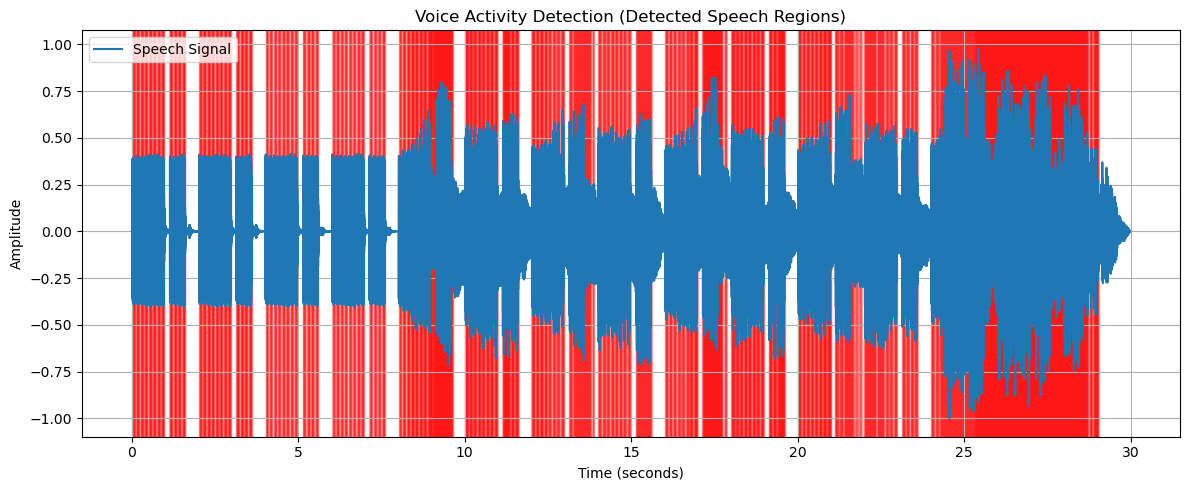

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(time_axis, signal, label="Speech Signal")

for i in range(num_frames):
    if vad[i]:
        start_time = i * frame_shift / sampling_rate
        end_time = (i * frame_shift + frame_size) / sampling_rate
        plt.axvspan(start_time, end_time, color='red', alpha=0.2)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Voice Activity Detection (Detected Speech Regions)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [7]:
# Save detected speech segments
os.makedirs("vad_segments", exist_ok=True)

segment_count = 0
inside_segment = False
seg_start = 0

for i in range(num_frames):
    if vad[i] and not inside_segment:
        seg_start = i * frame_shift
        inside_segment = True

    if inside_segment and (i == num_frames - 1 or not vad[i + 1]):
        seg_end = min(i * frame_shift + frame_size, len(signal))
        segment = signal[seg_start:seg_end]

        # Convert back to int16 for saving
        segment_int16 = np.int16(segment / np.max(np.abs(segment)) * 32767) if np.max(np.abs(segment)) > 0 else np.int16(segment)

        wavfile.write(
            f"vad_segments/segment_{segment_count}.wav",
            sampling_rate,
            segment_int16
        )

        segment_count += 1
        inside_segment = False

print("Total speech segments saved:", segment_count)

Total speech segments saved: 142
